Original max intensity (L_max): 651264.0

Processing with gamma:  0.51

E min = 0.000000, E max = 0.370241, E mean = 0.000481

K min = 1.66, K max = 104428.94, K mean = 24607.74
f_c (rightmost trough) = 0.9902
Original max intensity (L_max): 651264.0

Processing with gamma:  0.5

E min = 0.000000, E max = 0.370241, E mean = 0.000481

K min = 1.64, K max = 83255.46, K mean = 19624.62
f_c (rightmost trough) = 0.9863
Original max intensity (L_max): 651264.0

Processing with gamma:  0.43

E min = 0.000000, E max = 0.370241, E mean = 0.000481

K min = 1.53, K max = 17043.35, K mean = 4033.88
f_c (rightmost trough) = 0.9941
Original max intensity (L_max): 651264.0

Processing with gamma:  0.45

E min = 0.000000, E max = 0.370241, E mean = 0.000481

K min = 1.56, K max = 26814.60, K mean = 6336.35
f_c (rightmost trough) = 0.9824


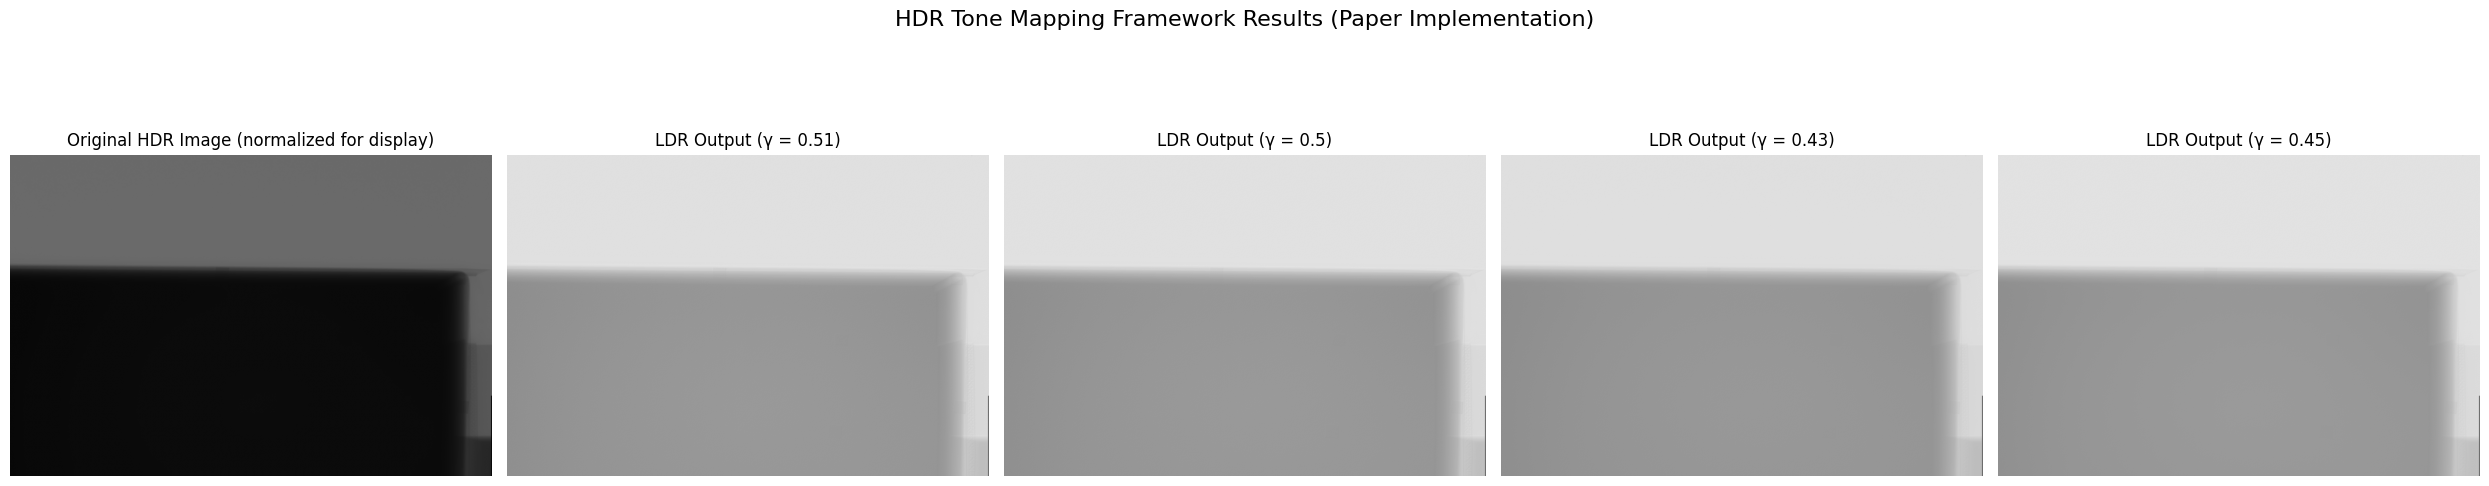


All results plotted successfully in Jupyter Notebook.


In [1]:
from utils import load_hdr, save_ldr
from tonemap import tonemap
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import generic_filter, laplace
import cv2
from typing import List, Any
from parameters import Parameters 
params = Parameters()


def run(input_path: str, output_path: str = None, gamma_values: List[float]=params.gamma_values):
    hdr = load_hdr(input_path)


    # =============================================
    # Prepare for plotting (just for exp)
    # =============================================
    fig, axs = plt.subplots(1, len(gamma_values) + 1, figsize=(5 * (len(gamma_values) + 1), 6))
    fig.suptitle("HDR Tone Mapping Framework Results (Paper Implementation)", fontsize=16)

    # Plot original input (normalized for display)
    I_display = np.clip(hdr) if hdr.max() > 0 else hdr
    axs[0].imshow(I_display, cmap='gray')
    axs[0].set_title("Original HDR Image (normalized for display)")
    axs[0].axis('off')


    # =============================================
    # Loop over each gamma value
    # =============================================
    for idx, gamma in enumerate(gamma_values):
        f_out = tonemap(hdr, gamma=gamma)


        # =============================================
        # Plot the LDR output (just for exp)
        # =============================================
        ldr_display = (f_out * 255.0).clip(0, 255).astype(np.uint8)
        axs[idx + 1].imshow(ldr_display, cmap='gray')
        axs[idx + 1].set_title(f"LDR Output (γ = {gamma})")
        axs[idx + 1].axis('off')

    plt.tight_layout()
    plt.show()
    print("\nAll results plotted successfully in Jupyter Notebook.")

# ====================== USAGE (in Jupyter Notebook) ======================
# Just run the cell below:
run("input.hdr")
# "input.hdr" is the "poor_battery_images_dataset.zip/5_Corner_Cathode_5/02_3072 x 3072_pos(2)_NG.hdr" file, but i renamed it to "input.hdr" for simplicity.
# you can test with any file, just update the image path and run ..